In [1]:
# Pool data across session and animals
import argparse
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
os.environ["PYDEVD_USE_FRAME_EVAL"] = "NO"
import re
import scipy.io as sio
import seaborn as sns
import pickle
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    silhouette_score,
    adjusted_rand_score,
    silhouette_samples,
)
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, KMeans
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.manifold import spectral_embedding   # same code SC uses
from sklearn.cluster._spectral import discretize 
from sklearn.model_selection import KFold, LeaveOneOut, train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.kernel_ridge import KernelRidge
from sklearn import linear_model
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import (
    ModelDesc,
    EvalEnvironment,
    Term,
    EvalFactor,
    LookupFactor,
    dmatrices,
    INTERCEPT,
)
from statsmodels.distributions.empirical_distribution import ECDF
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.colorbar as colorbar
import sys
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, LeaveOneOut
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.svm import SVC, LinearSVC

import importlib
import s2p_utils.processing_utils
import s2p_utils.data_loader
import plot_utils
from s2p_utils.data_loader import DataLoader

importlib.reload(s2p_utils.processing_utils)
importlib.reload(s2p_utils.data_loader)
importlib.reload(plot_utils)
from s2p_utils.data_loader import load_population_data
from s2p_utils.processing_utils import (
    reorder_clusters,
    build_knn,
    get_initial_cluster_labels
)
from plot_utils import (
    tsplot,
    standardize_plot_graphics,
    plot_PC_screenplot,
    plot_PCs,
    make_silhouette_plot,
    plot_activity_clusters,
    plot_cluster_pairs,
    plot_individual_trial_average_activity,
)

logger = logging.getLogger(__name__)

c:\Users\mzhou9\Anaconda3\envs\py3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
c:\Users\mzhou9\Anaconda3\envs\py3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


In [2]:
# Initialize parameters
data_dir = "Z:\\2p\\experiment1\\"
pre_cue_window = 3
post_cue_window = 17
delay_to_reward = 3
min_cell_prob = 0.5
neucoeff = 0.7
framerate = 5
target_frames = 300 # Should be the total time window * framerate * nCS, so 300 for the current settings
trial_types = ["CS1+", "CS2+", "CS3-"]
learning_stage = 'late'


# Set animals and days for early and late learning
if learning_stage == "early":
    result_dir = "Z:\\2p\\experiment1\\population_data\\early learning\\"
    animal_list = [
        "MZ_CA1_WD_F3",
        "MZ_CA1_WD_M5",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55"
    ]
    day_list = np.ones(7, dtype=int)
    subtrials = 'first10'

elif learning_stage == "intermediate":
    result_dir = "Z:\\2p\\experiment1\\population_data\\intermediate learning\\"
    animal_list = [
        "MZ_CA1_WD_F3",
        # "MZ_CA1_WD_M4/d1",
        "MZ_CA1_WD_M5",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55"
    ]
    day_list = [3, 3, 4, 4, 4, 4, 7]
    subtrials = 'all'
      
elif learning_stage == "late":
    result_dir = "Z:\\2p\\experiment1\\population_data\\late learning\\"
    animal_list = [
        "MZ_CA1_WD_F3",
        # "MZ_CA1_WD_M4/d5",
        "MZ_CA1_WD_M5",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55"
    ]   
    day_list = [7, 6, 5, 6, 6, 8, 12]
    subtrials = 'all'

In [3]:
# For plotting
window_size = 100
frames_to_reward = delay_to_reward * framerate
pre_window_size = pre_cue_window * framerate

In [4]:
# %debug
# Load and concatenate population data across animals
populationdata, animal_id = load_population_data(animal_list, day_list, data_dir, result_dir, target_frames, pre_cue_window, framerate, subtrials=subtrials)

# optional for training on certain trial types
cs1_data = populationdata[:, :window_size]
cs2_data = populationdata[:, window_size:2*window_size]
cs3_data = populationdata[:, 2*window_size:]
# train_data = np.hstack([cs1_data, cs3_data])
# trial_types = ['CS1+','CS3-']

train_data = populationdata
trial_types = ['CS1+', 'CS2+', 'CS3-']

# Define cache file paths before running PCA
pca_path = os.path.join(result_dir, "pca_model.pickle")
transformed_path = os.path.join(result_dir, "transformed_data.npy")

In [5]:
# Load cluster labels if exist
if os.path.exists(os.path.join(result_dir, "clusterlabels.npy")):
    newlabels = np.load(os.path.join(result_dir, "clusterlabels.npy"))   
    uniquelabels = list(set(newlabels))
    assert len(newlabels)==train_data.shape[0], "Cluster labels length does not match data points."
    print("Loaded existing cluster labels, skip clustering step.")

Loaded existing cluster labels, skip clustering step.


In [ ]:
## -------------------------------------------------------------------------------------------------------
## STEP 1: Dimensionality reduction with PCA
# Load saved data and models if exist
if all(os.path.exists(p) for p in [pca_path, transformed_path]):
    with open(pca_path, "rb") as f:
        pca_data = pickle.load(f)
        pca = pca_data["pca"]
        num_retained_pcs = pca_data["num_retained_pcs"]
        
    transformed_data = np.load(transformed_path)   
else:
    pca = PCA(n_components=min(train_data.shape[0], train_data.shape[1]), whiten=True)
    pca.fit(train_data)
    pca_vectors = pca.components_
    x = 100 * pca.explained_variance_ratio_
    xprime = x - (x[0] + (x[-1] - x[0]) / (x.size - 1) * np.arange(x.size))
    num_retained_pcs = np.argmin(xprime)

    # # dimension-reduced data on the first principal components
    transformed_data = pca.transform(train_data)
    np.save(os.path.join(result_dir, "transformed_data.npy"), transformed_data)
    
    # Save PCA model
    with open(pca_path, "wb") as f:
        pickle.dump({
            "pca": pca,
            "num_retained_pcs": num_retained_pcs
        }, f)       
    
    # Plot PC screen plot
    fig_pc_screenplot = plot_PC_screenplot(pca, x, num_retained_pcs)
    fig_pc_screenplot.savefig(
        os.path.join(result_dir, "PC_screenplot.png"), format="png"
    )
    plt.close(fig_pc_screenplot)

    # Plot PCs
    fig_pcs = plot_PCs(
        pca_vectors,
        num_retained_pcs,
        trial_types,
        window_size,
        pre_window_size,
        frames_to_reward,
        framerate,
    )
    fig_pcs.savefig(os.path.join(result_dir, "PCs.png"), format="png")
    plt.close(fig_pcs)

In [ ]:
## -------------------------------------------------------------------------------------------------------
## STEP 2: Clustering
# Choose model, options are "SC_discretize", "SC_kmeans", 
# "KMeans", "AgglomerativeClustering"
clustering_model = "SC_discretize"
clustering_path = os.path.join(result_dir, f"clustering_model_{clustering_model}.pickle")
labels_path = os.path.join(result_dir, f"clusterlabels.npy")

if all(os.path.exists(p) for p in [clustering_path, labels_path]):    
    
    with open(clustering_path, "rb") as f:
        cluster_data = pickle.load(f)
        model = cluster_data["model"]
        n_clusters = cluster_data["n_clusters"]
        n_nearest_neighbors = cluster_data["n_neighbors"]
    
    newlabels = np.load(labels_path)
    uniquelabels = list(set(newlabels))
    
else:    
    max_n_clusters = 10  # initialize nclusters, can run more but takes longer, 9 is relatively optimal
    # iTers = 100
    possible_n_clusters = np.arange(2, max_n_clusters + 1)  # has to be at least two
    possible_n_nearest_neighbors = np.array(
        [500, 750, 1000, 1250, 1500]
    )  # depends on the size of the data, for a data with 3000 neurons, maybe use up to 1500 
    
    silhouette_scores = np.nan*np.ones((possible_n_clusters.size,
                                        possible_n_nearest_neighbors.size,
                                        ))
    
    
    # Fit clusters with your clustering model of choice
    for nnidx, nn in enumerate(possible_n_nearest_neighbors):
        G = build_knn(transformed_data[:,:num_retained_pcs], nn)

        for n_clustersidx, n_clusters in enumerate(possible_n_clusters): 
            
            temp_data = transformed_data[:, :num_retained_pcs]
            labels = get_initial_cluster_labels(temp_data, clustering_model, n_clusters, nn, G=G)
            
            # silhouette coeff is  calculated as (mean near-cluster distance - mean intra-cluster distance) / max of the two, 
            # 1 is the best, -1 is the worst `                
            silhouette_scores[n_clustersidx, nnidx] = silhouette_score(transformed_data[:,:num_retained_pcs],
                                                                    labels,
                                                                    metric='cosine') 

            print('Done with numclusters = %d, num nearest neighbors = %d: score = %.3f'%(n_clusters,
                                                                                        nn,
                                                                                        np.nanmean(silhouette_scores[
                                                                                        n_clustersidx,
                                                                                        nnidx])))
    print("Done with model fitting")

    temp = {
        "possible_n_clusters": possible_n_clusters,
        "possible_n_nearest_neighbors": possible_n_nearest_neighbors,
        "silhouette_scores": silhouette_scores,
        "shape": "cluster_nn"
    }
    
    # Save the silhouette scores
    with open(os.path.join(result_dir, "silhouette_scores.pickle"), "wb") as f:
        pickle.dump(temp, f)
    # with open(os.path.join(result_dir, "silhouette_scores.pickle"), "rb") as f:
    #     silhouette_scores = pickle.load(f)
        
    # Identify optimal parameters from the above parameter space
    # temp = np.where(
    #     silhouette_scores["silhouette_scores"]== np.nanmax(silhouette_scores"silhouette_scores"]))
    # n_clusters = silhouette_scores["possible_n_clusters"][temp[0][0]]
    # n_nearest_neighbors = silhouette_scores["possible_n_nearest_neighbors"][temp[1][0]]
    
    
    temp = np.where(silhouette_scores==np.nanmax(silhouette_scores))
    n_clusters = temp[0][0]+2 
    n_nearest_neighbors = possible_n_nearest_neighbors[temp[1][0]]    
    
    print("Optimal number of clusters:",
          n_clusters,
          "; Optimal neighbors:",
          n_nearest_neighbors)
    
    
    model = SpectralClustering(n_clusters=n_clusters, 
                        affinity='nearest_neighbors', 
                        n_neighbors=n_nearest_neighbors,
                        assign_labels='discretize',
                        eigen_solver='arpack',
                        n_jobs=-1)
    model.fit(transformed_data[:, :num_retained_pcs])

    temp = silhouette_score(
        transformed_data[:, :num_retained_pcs], model.labels_, metric="cosine"
    )
    print(
        "Number of clusters = %d, average silhouette = %.3f"
        % (len(set(model.labels_)), temp)
    )

    # # Save this optimal clustering model.
    with open(clustering_path, "wb") as f:
        pickle.dump({
            "model": model,
            "n_clusters": n_clusters,
            "n_neighbors": n_nearest_neighbors
        }, f)
        
    newlabels = reorder_clusters(train_data, pre_window_size, model.labels_)
    # Create a new variable containing all unique cluster labels
    uniquelabels = list(set(newlabels))
    np.save(os.path.join(result_dir, "clusterlabels.npy"), newlabels)


In [ ]:
## -------------------------------------------------------------------------------------------------------
# Plots
# Plot animal's contribution for each cluster
df_contrib_by_animal = pd.DataFrame(
    {'Animal': animal_id,
        'Cluster': newlabels}
)
cluster_counts = df_contrib_by_animal.groupby(['Cluster', 'Animal']).size().unstack(fill_value=0)
cluster_percent_each_animal = cluster_counts.divide(cluster_counts.sum(axis=1), axis=0)
# print("\nNeuron counts per cluster per animal:")
# print(cluster_counts)
# Save as CSV
cluster_counts.to_csv(os.path.join(result_dir, "cluster_counts.csv"))
cluster_percent_each_animal.to_csv(os.path.join(result_dir, "cluster_percent.csv"))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_percent_each_animal, annot=True, cmap="viridis", fmt=".2f")
plt.title("Proportion of neurons from each animal in each cluster")
plt.ylabel("Cluster")
plt.xlabel("Animal")
plt.tight_layout()
plt.savefig(os.path.join(result_dir, "cluster_contribution_heatmap.png"))
plt.show()


In [ ]:
# Plot pie charts for each animal in subplots
num_animals = len(animal_list)
fig, axes = plt.subplots(1, num_animals, figsize=(num_animals * 3, 4))
colors = cm.get_cmap('tab20').colors  # Use a colormap with enough distinct colors

for ax, animal in zip(axes, animal_list):
    # Get the counts of each cluster for the current animal
    counts = cluster_counts[animal]
    
    # Plot pie chart
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
    ax.set_title(f"{animal}", fontsize=9)
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

fig.tight_layout()
fig.savefig(os.path.join(result_dir, "cluster_distribution_within_animal.png"))

In [ ]:
# Plot silhouette coefficient scores for each cluster
fig_silouette = make_silhouette_plot(
    transformed_data[:, :num_retained_pcs], model.labels_
)
fig_silouette.savefig(os.path.join(result_dir, "silouette.png"), format="png")
# plt.close(fig_silouette)

In [ ]:
# Plot activity clusters under each CS
fig_activity_cluster = plot_activity_clusters(
    train_data,
    uniquelabels,
    newlabels,
    trial_types,
    [15, 100],
    window_size,
    pre_window_size,
    frames_to_reward,
    framerate,
)
# fig_activity_cluster.savefig(
#     os.path.join(result_dir, "activity_clusters.png"), format="png"
# )

In [ ]:
# Plot all cluster pairs
fig_cluster_pairs = plot_cluster_pairs(
    transformed_data, uniquelabels, newlabels, num_retained_pcs
)
fig_cluster_pairs.savefig(os.path.join(result_dir, "cluster_pairs.png"), format="png")

In [6]:
def get_filtered_rois_per_animal_plane(animal_list, day_list, data_dir, oldlabels, target_day_list, skip_if_missing_plane_day=None):
    """
    Returns
    -------
    filtered_rois_per_animal_plane : dict
        Format:
            {
                animal1: {plane0: [roi_idx0, ...], plane1: [...] ...},
                animal2: {plane0: [...], ...},
                ...
            }
        Each list contains cell indices (0-based within each plane) ON DAY 1, which also have matches on the trained day
    """
    filtered_rois_per_animal_plane = {}
    newlabels_flag = {}
    
    if target_day_list is None:
        per_animal_req_day = None # use all days per animal
    else:
        per_animal_req_day = target_day_list
    
    for a, (day, animal) in enumerate(zip(day_list, animal_list)):
        top_animal_dir = os.path.join(data_dir, animal)
        main_dir = os.path.join(top_animal_dir, f"d{day}")
        file_dir = os.path.join(main_dir, "files")
        
        print(animal)
        # Load cell index for this trained day
        cells_idx = np.load(os.path.join(file_dir, "cell_idx.npy"), allow_pickle=True)
        num_planes = len(cells_idx)
        
        
        # Plane offsets for global indexing
        plane_offsets_for_global_idx = np.cumsum([0] + [len(x) for x in cells_idx[:-1]])
        filtered_rois_per_animal_plane[animal] = {}
        newlabels_flag[animal] = {}
        
        trained_day_col = str(day-1)
        
        for ip in range(num_planes):
            # Load ROI table for each animal and the day columns 
            ROI_table_across_sessions = pd.read_csv(os.path.join(top_animal_dir, f"ROI_table_full_plane{ip}.csv"))
            all_day_cols = [col for col in ROI_table_across_sessions.columns if re.match(r'^\d+$', str(col).strip())]

            # Find the rows where the trained day column matches the current plane's cell indices for all the target sessions
            matched_rows_on_trained_day = ROI_table_across_sessions[ROI_table_across_sessions[trained_day_col].isin(cells_idx[ip])]
            matched_rows_on_trained_day = matched_rows_on_trained_day.sort_values(by=trained_day_col)
            newlabels_flag[animal][ip] = np.full(len(matched_rows_on_trained_day), fill_value=-1)  # Initialize with -1
            
            # Skip the plane if data is missing for some days
            if skip_if_missing_plane_day and animal in skip_if_missing_plane_day:
                plane_to_skip = skip_if_missing_plane_day[animal]
                if plane_to_skip == ip:
                    print(f"Skipping animal {animal}, plane {ip}")
                    filtered_rois_per_animal_plane[animal][ip] = []
                    continue
                
            # correct for 0-based indexing
            if per_animal_req_day[a] is None:
                required_day_cols = all_day_cols
            else:
                required_day_cols = [str(d-1) for d in per_animal_req_day[a] if str(d) in all_day_cols]
            
            
            # Get the ROIs that also have matches on target day thats not -1 (both int or str)
            all_valid_mask = (matched_rows_on_trained_day[required_day_cols].astype(str) != '-1').all(axis=1)
            index_filtered_ROIs = np.flatnonzero(all_valid_mask.values).tolist()
            filtered_ROIs = matched_rows_on_trained_day[all_valid_mask].copy()
            
            # Get the remaining cell indices on trained day based on the target days
            remaining_cells = filtered_ROIs[trained_day_col].astype(int).values.tolist()
            
            # Get the new labels for these cells and sort by day 1 index
            global_indices = [plane_offsets_for_global_idx[ip] + idx for idx in remaining_cells]
            assert(len(global_indices) == len(filtered_ROIs)), "Length mismatch!"
            
            labels = np.asarray(oldlabels)[global_indices].tolist()
            filtered_ROIs['labels'] = labels

            # filtered_ROIs = filtered_ROIs.sort_values(by=trained_day_col)
            
            # # reorder labels accordingly and save as new labels
            # reordered_labels = filtered_ROIs['labels'].values.tolist()
            # newlabels_per_animal_plane.extend(labels)
            
            filtered_rois_per_animal_plane[animal][ip] = filtered_ROIs
            for row, label in zip(index_filtered_ROIs, labels):
                newlabels_flag[animal][ip][row] = label
            
            assert (len(filtered_rois_per_animal_plane[animal][ip]) == len(labels)), "Length mismatch!"
            # Now filtered_rois_per_animal_plane[animal][ip] is the list of cell indices within plane ip for animal, present on day 1 and in ROI table

    return filtered_rois_per_animal_plane, newlabels_flag

In [7]:
# Load ROI ID for each animal on the previous training day "late"
animal_list = [
        "MZ_CA1_WD_F3",
        "MZ_CA1_WD_M5",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55",
    ]
trained_day_list = [7, 6, 5, 6, 6, 8, 12]
target_day_list = [[1, 2, 3, 5, 10],
                   [1, 2, 3, 5, 10],
                   [1, 2, 3, 6, 9],
                   [1, 2, 3, 5, 9],
                   [1, 2, 3, 5, 10],
                   [1, 2, 3, 5, 7, 10],
                   [1, 2, 3, 9, 14]]
skip_map = {"MZ_CA1_WD_F3": 2} # (plane_index, day_index) to skip missing data
filtered_ROIs_across_sessions, filtered_labels = get_filtered_rois_per_animal_plane(animal_list, trained_day_list, data_dir, newlabels, target_day_list, skip_map)

MZ_CA1_WD_F3
Skipping animal MZ_CA1_WD_F3, plane 2
MZ_CA1_WD_M5
MZ_CA1_WD_M6
MZ_CA1_WD_M7
MZ_CA1_WD_M8
MZ_CA1_WD_JB_54
MZ_CA1_WD_JB_55


In [8]:
filtered_labels['MZ_CA1_WD_F3'][0]

array([ 1,  4,  1, -1,  5,  6, -1, -1,  7,  7,  8, -1, -1,  1,  4,  1,  7,
        2,  6,  8,  7,  6,  1,  0,  2,  5,  4, -1, -1, -1, -1, -1,  0, -1,
       -1, -1,  5,  5, -1,  6, -1,  1, -1,  2, -1,  1,  2, -1, -1,  6, -1,
        5, -1,  6,  0,  8,  5,  4, -1,  5, -1, -1, -1,  1,  7,  1,  8,  1,
       -1,  7, -1, -1, -1,  2, -1, -1, -1, -1,  3,  5,  1,  4, -1,  4, -1,
        4, -1,  8,  6,  7, -1,  8,  2,  8,  5,  0, -1, -1,  8, -1,  1,  8,
        1,  5,  4,  0,  1, -1, -1, -1,  5,  4, -1,  4,  1,  7,  0,  8, -1,
       -1,  3,  7, -1,  8, -1,  1, -1, -1,  4, -1,  1,  1,  0,  4, -1, -1,
       -1,  8, -1, -1,  7,  8, -1,  5,  7,  1, -1,  1, -1,  2, -1, -1, -1,
       -1, -1, -1,  6, -1, -1,  7, -1, -1,  5, -1, -1,  1, -1, -1,  5,  2,
        1,  1,  1,  6,  4, -1, -1,  8,  1,  5, -1, -1,  2,  1, -1,  7, -1,
        1, -1, -1,  7,  5, -1, -1,  8,  1, -1, -1, -1,  1,  4,  2, -1, -1,
       -1,  6, -1,  1, -1, -1, -1, -1, -1, -1,  8,  5, -1, -1, -1, -1, -1,
       -1, -1,  4, -1, -1

In [9]:
def load_population_data_filtered(
    animal_list, 
    day_list, 
    data_dir, 
    result_dir, 
    target_frames, 
    pre_cue_window, 
    framerate, 
    filtered_rois_per_animal_plane,   # <-- NEW ARG, dict: animal -> plane -> [cell_idx, ...]
    subtrials=None
):

    # pop_path = os.path.join(result_dir, "populationdata_filtered.npy")
    # id_path = os.path.join(result_dir, "animal_id_filtered.npy")
        
    # if os.path.exists(pop_path):
    #     return np.load(pop_path, allow_pickle=True), np.load(id_path, allow_pickle=True)

    populationdata_list = []
    animal_id = []
    foundcells_idx_full = []
    foundcells_flags_full = []
                 
    for a, (animal, day) in enumerate(zip(animal_list, day_list)):
        total_cells = 0
        print(animal)
        file_dir = os.path.join(data_dir, animal, "d"+str(day), "files")
        rawdata = np.load(os.path.join(file_dir, "F_around_cue_raw.npy"), allow_pickle=True)  # shape: (trial_types, ntrials, ncells, nframes)
        cells_idx = np.load(os.path.join(file_dir, "cell_idx.npy"), allow_pickle=True) # load cell index            
        total_cells = sum(len(x) for x in cells_idx)
        print(cells_idx)
        print(total_cells, " total number of cells loaded from ", animal)
        
        # Initialize per animal found-flag array of zeros with the length of ncells
        foundcell_flags_per_animal = np.zeros(total_cells, dtype=int)
        
        # Trials per cue and min across cues
        n_trials = [len(rawdata[i]) for i in range(rawdata.shape[0])]
        min_trials = np.min(n_trials)
        rng = np.random.default_rng() 
        
        # Build per-cue indices based on subtrials
        idxs_per_cue = []

        if subtrials is None or subtrials == 'all':
            K = min_trials
            for n in n_trials:
                if n == K:
                    idx = np.arange(n, dtype=int)
                else:
                    idx = rng.choice(n, size=K, replace=False)
                    idx = np.sort(idx)
                idxs_per_cue.append(idx)

        elif subtrials == 'first10':
            K = min(10, min_trials)
            for n in n_trials:
                idxs_per_cue.append(np.arange(min(n, K), dtype=int))

        elif subtrials == 'last10':
            K = min(10, min_trials)
            for n in n_trials:
                start = max(0, n - K)
                idxs_per_cue.append(np.arange(start, n, dtype=int))
        
        subset_raw = [np.take(a, idx, axis=0) for a, idx in zip(rawdata, idxs_per_cue)]
        subset_ave = np.mean(subset_raw, axis=1)  # average across all trials within the trial type, returning shape: (trial_types, ncells, nframes)
        baseline = np.mean(subset_ave[:, :, 0:int(pre_cue_window * framerate)], axis=2, keepdims=True)
        subset_ave = subset_ave - baseline  # baseline subtraction  
        # Now subset_ave: (trial_types, ncells, nframes) (ncells is total for the animal)

        # Get per-plane filtered indices and subset!
        # Concatenation order: [cells from plane 0][plane 1][plane2]...
        plane_offsets = np.cumsum([0] + [len(x) for x in cells_idx[:-1]])
        print(f'plane_offsets: {plane_offsets}')
        cell_list_full = np.concatenate([np.asarray(x) for x in cells_idx])  # Concatenated full cell list (as in data axis)

        for ip, filtered_ROI_table_per_plane in filtered_rois_per_animal_plane[animal].items():
            
            if ip >= len(cells_idx):
                foundcells_flags_full.extend([0]*len(filtered_ROI_table_per_plane))
                continue
            if len(filtered_ROI_table_per_plane)==0:  # skip empty planes
                continue
            # Compute global indices for the population axis for this animal
            # global_indices = [plane_offsets[ip] + idx for idx in filtered_ROI_table_per_plane]
            
            # Get the filtered plane's cell IDs (not indices)
            print(f'ip: {ip}')
            print(f'number of cells in the plane{ip}: {len(cells_idx[ip])}')
            
            cells_idx_this_plane = np.array(cells_idx[ip])
            found_input_indices = []        # indices into original filtered_ROI_table_per_plane
            found_cells_idx_indices = []    # indices into cells_idx[ip]
            
            # Get the ROI indices on the test day (day-1)
            ROI_on_test_day = filtered_ROI_table_per_plane[str(day-1)].astype(int).tolist()
            
            for in_idx, cellnum in enumerate(ROI_on_test_day):
                match = np.where(cells_idx_this_plane == cellnum)[0]
                if match.size > 0:
                    found_input_indices.append(in_idx)
                    found_cells_idx_indices.append(match[0])
            
            found_flags = [1 if np.any(cells_idx_this_plane == cellnum) else 0 for cellnum in ROI_on_test_day]
            print(found_flags)
            
            if not found_cells_idx_indices:
                continue
                    
            # Get the per-plane-to-global axis-1 indices
            cell_ids_found = cells_idx_this_plane[found_cells_idx_indices]
            # Find these global indices as in cell_list_full (concatenated across all planes for the animal)
            global_indices = [int(np.where(cell_list_full == cell_id)[0][0]) for cell_id in cell_ids_found]
            print(global_indices)
            
            foundcell_flags_per_animal[global_indices] = 1  # mark found cells in the per-animal flag array
            
            assert(len(global_indices) == len(found_input_indices)), "Length mismatch!"
            tempdata = subset_ave.transpose(1, 0, 2)[global_indices]
            
            assert(tempdata.shape[0] == len(found_input_indices)), "Length mismatch!"
            foundcells_idx_full.extend(found_input_indices)
            # print(f'data shape: {tempdata.shape}')

            # Use these to select rows from subset_ave over the ncells axis
            # tempdata = subset_ave.transpose(1, 0, 2)[global_indices]  # (n_filtered, trial_types, nframes)
            # n_filtered, n_types, n_frames = tempdata.shape
            # tempdata = tempdata.reshape(n_filtered, -1)
            # pad/crop
            
            # tempdata = subset_ave.transpose(1, 0, 2)[ROI_on_test_day]  # (n_cells_filtered, trial_types, nframes)
            
            n_cells = tempdata.shape[0]
            tempdata = tempdata.reshape(n_cells, -1)   # (n_cells, trial_types * nframes) 
            # print(f'rehsaped data shape: {tempdata.shape}')
                      
            if tempdata.shape[1] < target_frames:
                pad_width = target_frames - tempdata.shape[1]
                tempdata = np.pad(tempdata, ((0, 0), (0, pad_width)), mode='constant', constant_values=0)
            elif tempdata.shape[1] > target_frames:
                tempdata = tempdata[:, :target_frames]
            populationdata_list.append(tempdata)
            animal_id.extend([animal] * len(global_indices))

            assert(len(ROI_on_test_day) == len(found_flags)), "indice and flag mismatch!"
        
        # Extend the global found cell flags for this animal
        foundcells_flags_full.extend(foundcell_flags_per_animal.tolist())
        
    if populationdata_list:
        populationdata  = np.vstack(populationdata_list)
        animal_id = np.array(animal_id)
    else:   # fallback in case there's no cell for any animal/plane
        populationdata = np.zeros((0, target_frames))
        # animal_id = np.array([])

    # np.save(pop_path, populationdata)
    # np.save(id_path, animal_id)    
    return populationdata, animal_id, foundcells_idx_full, foundcells_flags_full

In [10]:
test_day_list = np.ones(7, dtype=int) # input signle day for each animal
animal_list = [
        "MZ_CA1_WD_F3",
        "MZ_CA1_WD_M5",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55",
    ]
filtered_d1, animal_list, foundcell_idx, foundcell_flags = load_population_data_filtered(
    animal_list, 
    test_day_list, 
    data_dir, 
    result_dir, 
    target_frames, 
    pre_cue_window, 
    framerate, 
    filtered_ROIs_across_sessions)

MZ_CA1_WD_F3
[list([0, 2, 5, 6, 7, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 27, 28, 29, 30, 31, 33, 34, 36, 37, 41, 42, 46, 47, 53, 55, 56, 57, 58, 63, 64, 66, 71, 72, 73, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 91, 92, 96, 97, 98, 101, 103, 105, 106, 107, 109, 112, 113, 114, 115, 116, 118, 120, 122, 124, 125, 128, 129, 130, 132, 134, 135, 137, 139, 140, 141, 143, 144, 145, 147, 154, 155, 158, 159, 160, 164, 167, 170, 172, 174, 175, 176, 180, 181, 183, 184, 185, 188, 190, 195, 196, 197, 200, 201, 202, 207, 212, 213, 214, 216, 217, 218, 221, 222, 225, 226, 227, 230, 232, 237, 239, 241, 242, 243, 244, 245, 246, 249, 251, 253, 254, 255, 256, 259, 261, 262, 263, 264, 267, 268, 269, 270, 271, 274, 275, 278, 280, 283, 287, 288, 289, 290, 294, 295, 296, 297, 299, 300, 301, 302, 303, 304, 306, 307, 310, 314, 315, 319, 320, 321, 325, 326, 328, 330, 335, 336, 337, 338, 341, 345, 346, 347, 348, 349, 351, 353, 356, 358, 363, 372, 374, 378, 379, 382, 384, 385, 386, 388, 390, 391, 392, 396, 400, 

In [84]:
pd.set_option('display.max_rows', None) 
filtered_ROIs_across_sessions['MZ_CA1_WD_F3'][0]

,Neuron_ID,0,1,2,3,4,5,6,7,8,9,labels
136,136,54,59,4,19,29,6,0,118,12,41.0,1
1276,1276,154,43,131,36,16,20,1,37,3,5.0,4
46,46,27,9,1,0,2,19,3,1,5,811.0,1
319,319,408,63,38,20,38,25,6,9,8,6.0,5
34,34,22,36,2,15,70,23,7,50,65,9.0,6
234,234,123,54,15,106,160,79,10,29,17,21.0,7
269,269,131,40,64,18,7,47,11,33,37,60.0,7
171,171,87,20,14,23,9,1,12,12,18,62.0,8
256,256,135,75,88,41,34,26,16,7,64,55.0,1
1493,1493,7,0,3,1,23,156,17,45,52,89.0,4


In [84]:
foundcell_flags

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,


In [80]:
foundcell_labels_d1 = [label for label, flag in zip(newlabels, foundcell_flags) if flag == 1]

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles wi

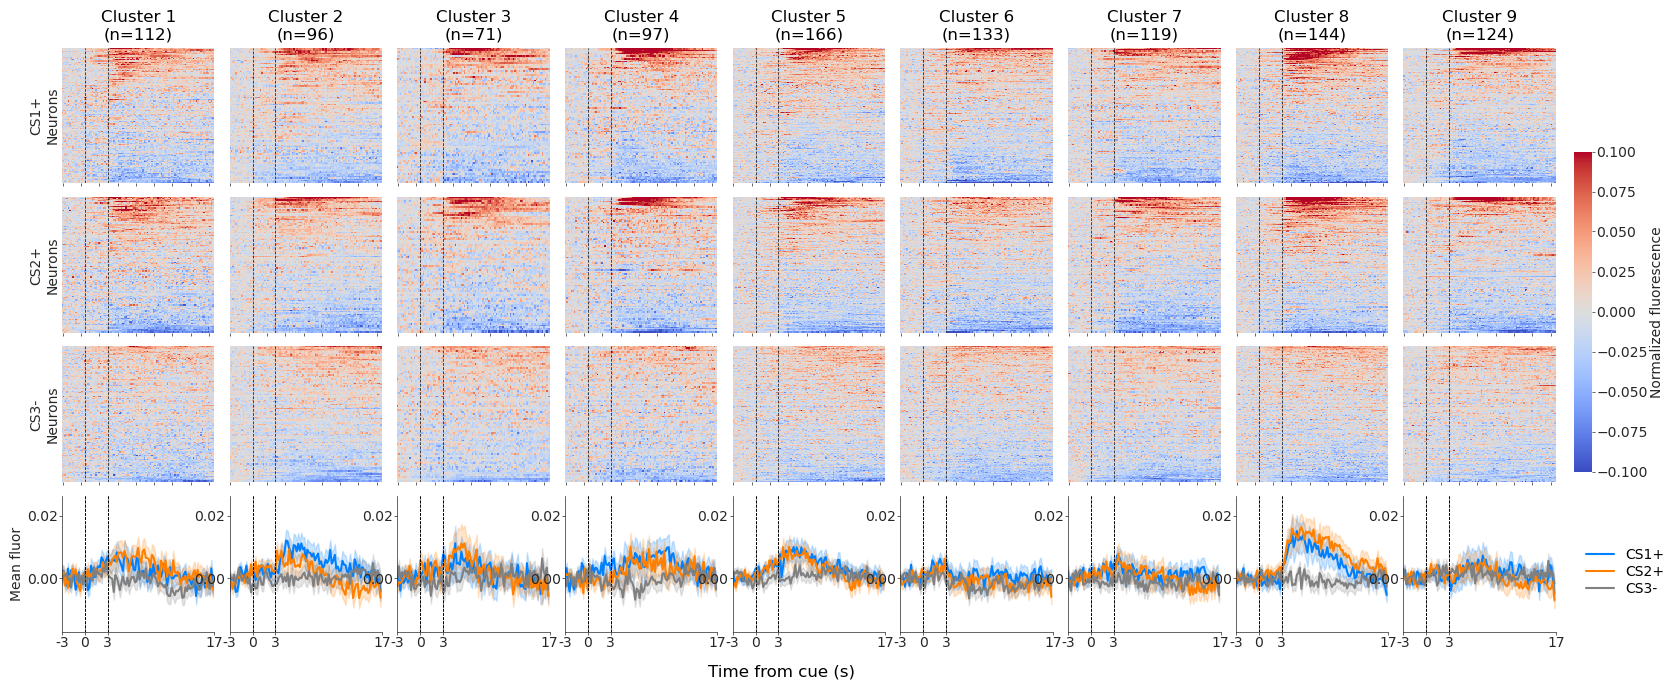

In [81]:
# Plot activity clusters under each CS
fig_activity_cluster_d1 = plot_activity_clusters(
    filtered_d1,
    uniquelabels,
    foundcell_labels_d1,
    trial_types,
    [15, 100],
    window_size,
    pre_window_size,
    frames_to_reward,
    framerate,
)
# fig_activity_cluster.savefig(
#     os.path.join(result_dir, "activity_clusters_day1.png"), format="png"
# )

In [54]:
filtered_ROIs_across_sessions['MZ_CA1_WD_JB_54'][0]

,Neuron_ID,0,1,2,3,4,5,6,7,8,9,10,11,labels
927,927,21,3,2,8,6,6,11,0,10,12,37,-1,1
1,1,9,1,0,14,5,0,6,1,24,20,36,-1,4
1577,1577,41,102,7,4,0,1,2,2,0,271,232,328,4
62,62,31,60,570,1302,108,33,66,4,239,74,200,0,8
1477,1477,33,13,1,1,7,42,0,5,6,1429,985,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720,720,713,569,455,1121,1168,928,1264,1147,987,1005,529,437,6
908,908,427,1006,564,590,1174,724,887,1152,651,472,490,727,1
1153,1153,324,539,161,218,289,509,110,1154,153,280,201,336,0
1459,1459,380,684,976,763,1182,387,314,1155,902,37,89,380,8


In [55]:
# Test on the same day
test_day_list = [7, 6, 5, 6, 6, 8, 12]
animal_list = [
        "MZ_CA1_WD_F3",
        "MZ_CA1_WD_M5",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55",
    ]
filtered_dtrained, animal_list, foundcell_idx_dt, foundcell_flags_dt = load_population_data_filtered(
    animal_list, 
    test_day_list, 
    data_dir, 
    result_dir, 
    target_frames, 
    pre_cue_window, 
    framerate, 
    filtered_ROIs_across_sessions)

foundcell_labels_dtrained = [label for label, flag in zip(newlabels_filtered, foundcell_flags) if flag == 1]

MZ_CA1_WD_F3
1635  total number of cells loaded from  MZ_CA1_WD_F3
plane_offsets: [   0  388  854 1297]
ip: 0
number of cells in the plane0: 388
data shape: (158, 3, 100)
rehsaped data shape: (158, 300)
plane_offsets: [   0  388  854 1297]
ip: 1
number of cells in the plane1: 466
data shape: (191, 3, 100)
rehsaped data shape: (191, 300)
plane_offsets: [   0  388  854 1297]
ip: 3
number of cells in the plane3: 338
data shape: (115, 3, 100)
rehsaped data shape: (115, 300)
MZ_CA1_WD_M5
1037  total number of cells loaded from  MZ_CA1_WD_M5
plane_offsets: [  0 450 930]
ip: 0
number of cells in the plane0: 450
data shape: (18, 3, 100)
rehsaped data shape: (18, 300)
plane_offsets: [  0 450 930]
ip: 1
number of cells in the plane1: 480
data shape: (48, 3, 100)
rehsaped data shape: (48, 300)
plane_offsets: [  0 450 930]
ip: 2
number of cells in the plane2: 107
data shape: (17, 3, 100)
rehsaped data shape: (17, 300)
MZ_CA1_WD_M6
367  total number of cells loaded from  MZ_CA1_WD_M6
plane_offsets:

In [61]:
print(len(newlabels_filtered))
print(len(foundcell_flags))


foundcell_flags

1603
1603


[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles wi

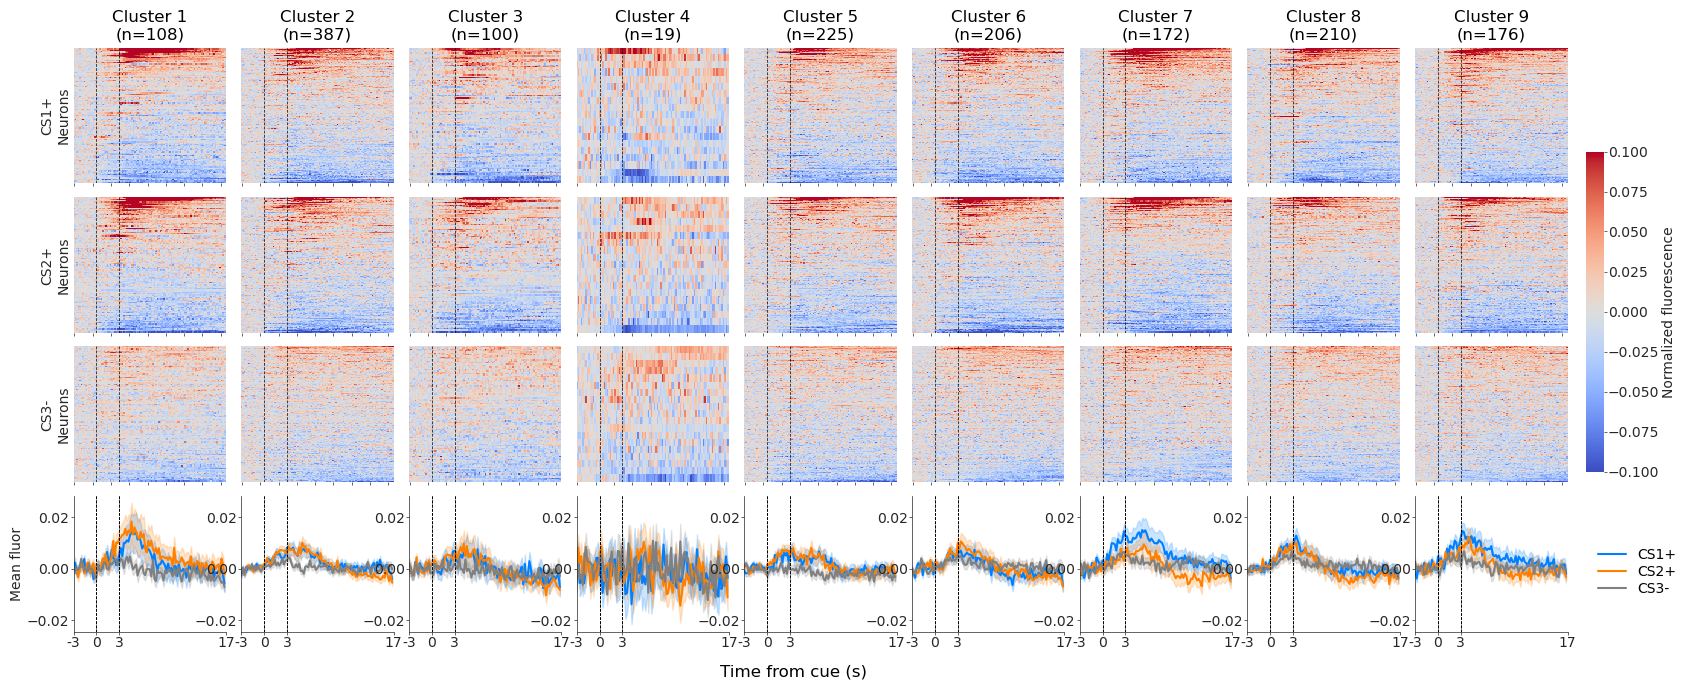

In [56]:
fig_activity_cluster_dtrained = plot_activity_clusters(
    filtered_dtrained,
    uniquelabels,
    foundcell_labels_dtrained,
    trial_types,
    [15, 100],
    window_size,
    pre_window_size,
    frames_to_reward,
    framerate,
)

In [ ]:
# Plot CS2 activity clustered by CS1vsCS3
# cs2_data = pca.transform(cs2_data)[:, :num_retained_pcs]
colors_for_key = {}
colors_for_key["CS1+"] = (0, 0.5, 1)
colors_for_key["CS2+"] = (1, 0.5, 0)
colors_for_key["CS3-"] = (0.5, 0.5, 0.5)
trial_types = ['CS1+', 'CS3-']
global_min = np.inf
global_max = -np.inf

fig, axs = plt.subplots(1, len(uniquelabels), figsize=(3*len(uniquelabels), 3))
for c, cluster in enumerate(uniquelabels):
    for k, tempkey in enumerate(trial_types):
        temp = train_data[
            np.where(newlabels == cluster)[0],
            k * window_size : (k + 1) * window_size,
        ]
        if temp.size > 0:
            mean_response = np.mean(temp, axis=0)
            global_min = min(global_min, np.min(mean_response))
            global_max = max(global_max, np.max(mean_response))
        
        ax = axs[c] if n_clusters > 1 else axs
        ax = tsplot(
                    temp,
                    ax=ax,
                    color=colors_for_key[tempkey],
                    label=tempkey if (cluster == (len(uniquelabels) - 1)) else None,
                )
        ax.axvline(pre_window_size, linestyle="--", color="k", linewidth=0.5)
        ax.axvline(
            pre_window_size + frames_to_reward,
            linestyle="--",
            color="k",
            linewidth=0.5,
        )
        ax.set_xticks(
            [0, pre_window_size, pre_window_size + frames_to_reward, window_size]
        )
        ax.set_xticklabels(
            [
                str(int((a - pre_window_size + 0.0) / framerate))
                for a in [
                    0,
                    pre_window_size,
                    pre_window_size + frames_to_reward,
                    window_size,
                ]
            ]
        )
        
    # Plot CS2 activity
    cs2_data_bycluster = cs2_data[newlabels == cluster]
    ax = tsplot(
            cs2_data[newlabels == cluster],
            ax=ax,
            color=colors_for_key['CS2+'],
            label=tempkey if (cluster == (len(uniquelabels) - 1)) else None,
        )
    if cluster == 0:
        buffer = 0.01
        ax.set_ylim([global_min - buffer, global_max + buffer])
    else:
        ax.set_yticks([])
    
    ax.legend(
        bbox_to_anchor=(0.94, 0.22),
        bbox_transform=fig.transFigure,
        frameon=False,
    )
    standardize_plot_graphics(ax)    
    axs[0].set_ylabel("Mean fluor")
    axs[cluster].set_title(
        "Cluster %d\n" % (cluster + 1)
    )
    fig.text(
        0.5,
        0.05,
        "Time from cue (s)",
        fontsize=12,
        horizontalalignment="center",
        verticalalignment="center",
        rotation="horizontal",
    )
fig.show()
fig.tight_layout()
# plt.show()
fig.savefig(os.path.join(result_dir, "CS2_activity_by_CS1cluster.png"), format='png')

In [ ]:
newdir = os.path.join(result_dir, 'all trials')
pop_path = os.path.join(newdir, "populationdata.npy")

popdata_all = np.load(pop_path, allow_pickle=True)

In [ ]:
from scipy.ndimage import gaussian_filter1d

traj_data = transformed_data.T  # shape: [300 timepoints, n_PCs]

# Split into three conditions
timesteps = 100
cs1_traj = traj_data[0:100, :]
cs2_traj = traj_data[100:200, :]
cs3_traj = traj_data[200:300, :]

cs1_traj = gaussian_filter1d(cs1_traj, sigma=2, axis=0)
cs2_traj = gaussian_filter1d(cs2_traj, sigma=2, axis=0)
cs3_traj = gaussian_filter1d(cs3_traj, sigma=2, axis=0)

# Plot the first 3 principal components
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(cs1_traj[:, 0], cs1_traj[:, 1], cs1_traj[:, 2], color=colors_for_key['CS1+'], label='CS1+')
ax.plot(cs2_traj[:, 0], cs2_traj[:, 1], cs2_traj[:, 2], color=colors_for_key['CS2+'], label='CS2+')
# ax.plot(cs3_traj[:, 0], cs3_traj[:, 1], cs3_traj[:, 2], color='b', label='CS3+')

# Mark start and end points
ax.scatter(cs1_traj[0, 0], cs1_traj[0, 1], cs1_traj[0, 2], color=colors_for_key['CS1+'], marker='o')
ax.scatter(cs2_traj[0, 0], cs2_traj[0, 1], cs2_traj[0, 2], color=colors_for_key['CS2+'], marker='o')
# ax.scatter(cs3_traj[0, 0], cs3_traj[0, 1], cs3_traj[0, 2], color='b', marker='o')

ax.scatter(cs1_traj[-1, 0], cs1_traj[-1, 1], cs1_traj[-1, 2], color=colors_for_key['CS1+'], marker='x')
ax.scatter(cs2_traj[-1, 0], cs2_traj[-1, 1], cs2_traj[-1, 2], color=colors_for_key['CS2+'], marker='x')
# ax.scatter(cs3_traj[-1, 0], cs3_traj[-1, 1], cs3_traj[-1, 2], color='b', marker='x')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

all_trials_data = transformed_data.T.reshape(len(trial_types), window_size, -1)


colors_for_key = {}
colors_for_key["CS1+"] = (0, 0.5, 1)
colors_for_key["CS2+"] = (1, 0.5, 0)
colors_for_key["CS3-"] = (0.5, 0.5, 0.5)

labels_unique = sorted(set(labels))  # e.g., ['CS1+', 'CS2+', 'CS3+']

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for label in labels_unique:
    # Get indices for this condition
    idx = [i for i, l in enumerate(labels) if l == label]

    for i in idx:
        traj = all_trials_data[i]  # shape: [timepoints, n_pcs]
        start = traj[0, :3]  # first 3 PCs
        end = traj[-1, :3]

        # Connect start to end
        ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], 
                color=colors_for_key[label], alpha=0.4)

        # Mark points
        ax.scatter(*start, color=colors_for_key[label], marker='o', s=20)  # start
        ax.scatter(*end, color=colors_for_key[label], marker='x', s=30)    # end

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Start and End of Neural Trajectories')
ax.legend(labels_unique)
plt.show()

In [ ]:
all_trials_data = transformed_data.reshape(len(trial_types), window_size, -1)
